# Collector Location Clustering

Notebook ini memilih **K-Means** untuk membagi sebaran lokasi penyetor menjadi tiga area rekomendasi collector. Collector dapat mendaftar melalui website, sedangkan sistem membantu menunjukkan area yang masih potensial untuk dilayani. Centroid menjadi pusat area rekomendasi, bukan alamat bangunan collector yang wajib digunakan.

**Alasan memilih K-Means:** data memiliki banyak titik koordinat tanpa label cluster. K-Means dapat membagi seluruh penyetor secara otomatis berdasarkan kedekatan lokasi sekaligus menghasilkan titik pusat untuk setiap kelompok.

Output utama:

- Cluster 1
- Cluster 2
- Cluster 3
- pusat dan radius setiap area rekomendasi,
- peringkat area paling strategis, dan
- scatter plot sebaran penyetor beserta centroid.

In [57]:
from pathlib import Path
import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

plt.style.use("ggplot")
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

## 1. Memuat data lokasi penyetor

Setiap penyetor memiliki koordinat `latitude` dan `longitude`. Kolom `average_volume` disimpan untuk merangkum potensi volume per cluster, tetapi pembentukan cluster hanya menggunakan lokasi agar rekomendasi collector berfokus pada kedekatan geografis.

In [58]:
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
data_path = project_root / "data" / "collector_locations_dummy.csv"

df = pd.read_csv(data_path)
df.head()

,collector_id,collector_name,latitude,longitude,average_volume
0,DEP001,Penyetor 001,-6.174500,106.822700,145
1,DEP002,Penyetor 002,-6.181200,106.829400,210
2,DEP003,Penyetor 003,-6.168800,106.835100,175
3,DEP004,Penyetor 004,-6.190500,106.817800,240
4,DEP005,Penyetor 005,-6.156900,106.824500,130


In [59]:
required_columns = [
    "collector_id",
    "collector_name",
    "latitude",
    "longitude",
    "average_volume",
]

missing_columns = [column for column in required_columns if column not in df.columns]
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

if df[required_columns].isna().any().any():
    raise ValueError("The dataset contains missing values.")

if not df["latitude"].between(-90, 90).all():
    raise ValueError("Latitude values must be between -90 and 90.")

if not df["longitude"].between(-180, 180).all():
    raise ValueError("Longitude values must be between -180 and 180.")

print(f"Number of collectors: {len(df)}")
print(f"Missing values: {df[required_columns].isna().sum().sum()}")

Number of collectors: 45
Missing values: 0


## 2. Metode terpilih: K-Means

K-Means dipilih sebagai satu-satunya metode clustering. Jumlah cluster ditetapkan menjadi tiga sesuai kebutuhan tiga area collector. `random_state` digunakan agar hasil dapat direproduksi.

In [60]:
coordinate_columns = ["latitude", "longitude"]
coordinates = df[coordinate_columns]

number_of_clusters = 3
kmeans = KMeans(n_clusters=number_of_clusters, random_state=42, n_init=10)
raw_labels = kmeans.fit_predict(coordinates)
raw_centroids = kmeans.cluster_centers_

# Sort centroids from west to east to produce stable business-friendly labels.
sorted_raw_labels = np.argsort(raw_centroids[:, 1])
label_mapping = {
    int(raw_label): f"Cluster {position + 1}"
    for position, raw_label in enumerate(sorted_raw_labels)
}

df["cluster"] = [label_mapping[int(label)] for label in raw_labels]

centroid_rows = []
for raw_label, centroid in enumerate(raw_centroids):
    centroid_rows.append({
        "cluster": label_mapping[raw_label],
        "collector_latitude": centroid[0],
        "collector_longitude": centroid[1],
    })

centroids_df = pd.DataFrame(centroid_rows).sort_values("cluster").reset_index(drop=True)
centroids_df

c:\Users\LENOVO\miniconda3\envs\mlenv\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,cluster,collector_latitude,collector_longitude
0,Cluster 1,-6.177227,106.824533
1,Cluster 2,-6.277373,106.832487
2,Cluster 3,-6.225947,106.889780


Centroid merupakan hasil K-Means dan digunakan sebagai pusat area rekomendasi, bukan lokasi final collector. Collector yang mendaftar dapat memilih lokasi operasional di dalam radius area tersebut. Lokasi final tetap mempertimbangkan akses jalan, legalitas, biaya lahan, dan kapasitas.

## 3. Menentukan area paling strategis

Sistem menghasilkan **tiga area rekomendasi pilihan** yang diprioritaskan berdasarkan kepadatan potensi volume. Prioritas strategis dihitung dengan rumus:

```
strategic_score = potential_volume / service_area_km2
```

Di mana `service_area_km2 = π × radius_km²`. Area dengan `strategic_score` tertinggi mendapat `is_most_strategic = true`.

**Penjelasan `is_most_strategic`:**
- `is_most_strategic = true`: Area dengan strategic_score tertinggi (potensi volume padat dengan cakupan efisien)
- `is_most_strategic = false`: Dua area lainnya yang masih potensial namun kurang optimal dari segi strategis

Anggota baru dapat memilih salah satu dari tiga area ini, dengan rekomendasi untuk memilih area dengan `is_most_strategic = true` untuk hasil optimal.

Setiap area menghasilkan output dengan struktur berikut:

- `recommended_location`: rekomendasi koordinat pusat collector (latitude, longitude),
- `radius_km`: persentil ke-90 jarak penyetor dari titik rekomendasi,
- `potential_volume`: total potensi volume penyetor dalam area,
- `is_most_strategic`: penanda area dengan prioritas strategis tertinggi.

In [61]:
def haversine_distance(latitude_1, longitude_1, latitude_2, longitude_2):
    earth_radius_km = 6371.0088

    latitude_1_rad = np.radians(latitude_1)
    latitude_2_rad = np.radians(latitude_2)
    latitude_difference = np.radians(latitude_2 - latitude_1)
    longitude_difference = np.radians(longitude_2 - longitude_1)

    haversine_value = (
        np.sin(latitude_difference / 2) ** 2
        + np.cos(latitude_1_rad)
        * np.cos(latitude_2_rad)
        * np.sin(longitude_difference / 2) ** 2
    )
    angular_distance = 2 * np.arctan2(
        np.sqrt(haversine_value), np.sqrt(1 - haversine_value)
    )

    return earth_radius_km * angular_distance


df = df.merge(centroids_df, on="cluster", how="left")
df["distance_to_centroid_km"] = df.apply(
    lambda row: haversine_distance(
        row["latitude"],
        row["longitude"],
        row["collector_latitude"],
        row["collector_longitude"],
    ),
    axis=1,
)

cluster_summary = (
    df.groupby("cluster", as_index=False)
    .agg(
        collector_count=("collector_id", "count"),
        potential_volume=("average_volume", "sum"),
        average_collector_volume=("average_volume", "mean"),
        radius_km=(
            "distance_to_centroid_km",
            lambda distances: np.percentile(distances, 90),
        ),
    )
    .merge(centroids_df, on="cluster", how="left")
    .sort_values("cluster")
    .reset_index(drop=True)
)

cluster_summary["cluster_id"] = (
    cluster_summary["cluster"].str.extract(r"(\d+)")[0].astype(int)
)
cluster_summary["service_area_km2"] = np.pi * cluster_summary["radius_km"] ** 2
cluster_summary["strategic_score"] = (
    cluster_summary["potential_volume"] / cluster_summary["service_area_km2"]
)
cluster_summary["strategic_rank"] = (
    cluster_summary["strategic_score"]
    .rank(method="dense", ascending=False)
    .astype(int)
)

cluster_summary

,cluster,collector_count,potential_volume,average_collector_volume,radius_km,collector_latitude,collector_longitude,cluster_id,service_area_km2,strategic_score,strategic_rank
0,Cluster 1,15,2810,187.333333,2.957964,-6.177227,106.824533,1,27.487524,102.228195,1
1,Cluster 2,15,3175,211.666667,3.679682,-6.277373,106.832487,2,42.537358,74.640272,3
2,Cluster 3,15,3215,214.333333,3.198250,-6.225947,106.889780,3,32.134741,100.047485,2


In [62]:
cluster_outputs = []

for _, row in cluster_summary.iterrows():
    cluster_outputs.append({
        "recommended_location": {
            "latitude": round(float(row["collector_latitude"]), 6),
            "longitude": round(float(row["collector_longitude"]), 6),
        },
        "radius_km": round(float(row["radius_km"]), 2),
        "potential_volume": int(row["potential_volume"]),
        "is_most_strategic": bool(row["strategic_rank"] == 1),
    })

cluster_outputs = sorted(cluster_outputs, key=lambda area: area["is_most_strategic"], reverse=True)
print(json.dumps(cluster_outputs, indent=2))

silhouette = silhouette_score(coordinates, raw_labels)
print(f"Silhouette score: {silhouette:.4f}")

[
  {
    "recommended_location": {
      "latitude": -6.177227,
      "longitude": 106.824533
    },
    "radius_km": 2.96,
    "potential_volume": 2810,
    "is_most_strategic": true
  },
  {
    "recommended_location": {
      "latitude": -6.277373,
      "longitude": 106.832487
    },
    "radius_km": 3.68,
    "potential_volume": 3175,
    "is_most_strategic": false
  },
  {
    "recommended_location": {
      "latitude": -6.225947,
      "longitude": 106.88978
    },
    "radius_km": 3.2,
    "potential_volume": 3215,
    "is_most_strategic": false
  }
]
Silhouette score: 0.6068


**Interpretasi:** `radius_km` menggunakan persentil ke-90 agar area tidak terlalu dipengaruhi outlier lokasi. `is_most_strategic` ditentukan berdasarkan `strategic_score` (potensi volume per km²) tertinggi, yang artinya area tersebut memiliki konsentrasi penyetor paling tinggi relatif terhadap luasnya. Output menampilkan **3 area pilihan** yang sudah diurutkan dengan area paling strategis di urutan pertama.

## 4. Visualisasi scatter plot

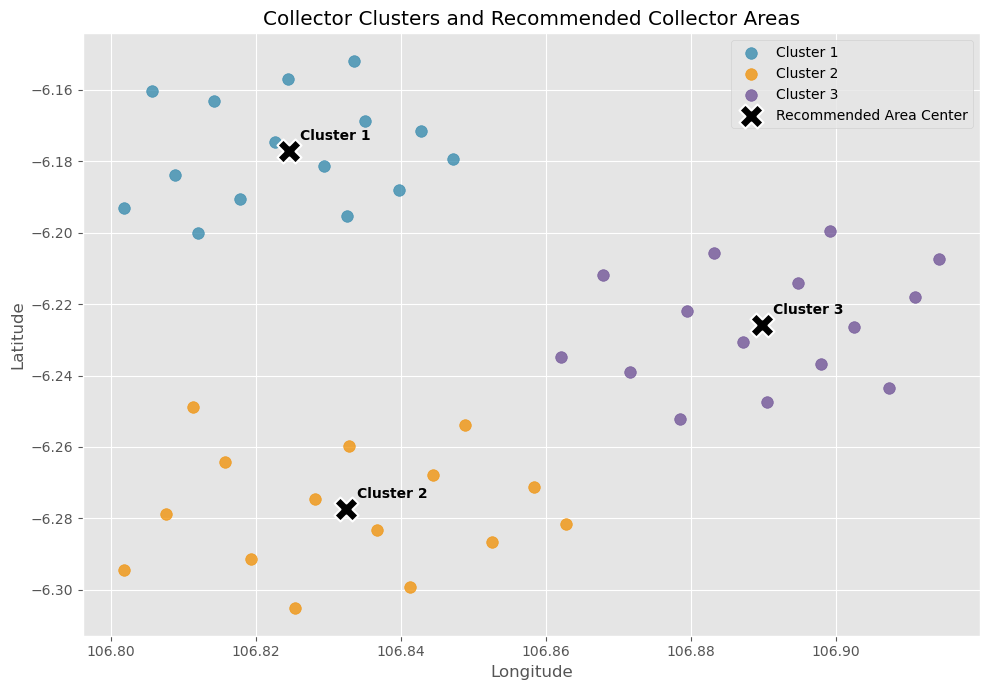

In [63]:
cluster_colors = {
    "Cluster 1": "#2E86AB",
    "Cluster 2": "#F18F01",
    "Cluster 3": "#6A4C93",
}

fig, ax = plt.subplots(figsize=(10, 7))

for cluster_name, cluster_data in df.groupby("cluster"):
    ax.scatter(
        cluster_data["longitude"],
        cluster_data["latitude"],
        s=70,
        alpha=0.75,
        color=cluster_colors[cluster_name],
        label=cluster_name,
    )

ax.scatter(
    centroids_df["collector_longitude"],
    centroids_df["collector_latitude"],
    marker="X",
    s=300,
    color="black",
    edgecolor="white",
    linewidth=1.5,
    label="Recommended Area Center",
)

for _, row in centroids_df.iterrows():
    ax.annotate(
        row["cluster"],
        (row["collector_longitude"], row["collector_latitude"]),
        xytext=(8, 8),
        textcoords="offset points",
        fontweight="bold",
    )

ax.set(
    title="Collector Clusters and Recommended Collector Areas",
    xlabel="Longitude",
    ylabel="Latitude",
)
ax.legend()
plt.tight_layout()
plt.show()

**Interpretasi:** Setiap warna menunjukkan satu area rekomendasi. Simbol X hitam adalah pusat area, bukan lokasi collector yang sudah terdaftar. Calon collector dapat menggunakan area dan radius tersebut sebagai panduan memilih wilayah operasional. Area dengan `strategic_rank = 1` memiliki prioritas tertinggi.

## 5. Rekomendasi area untuk collector

Fungsi berikut menerima koordinat calon collector atau penyetor dan membandingkannya dengan tiga pusat area menggunakan rumus Haversine. Hasilnya menunjukkan area rekomendasi terdekat.

In [64]:
def recommend_collector(latitude, longitude, collector_locations):
    recommendations = collector_locations.copy()
    recommendations["distance_km"] = recommendations.apply(
        lambda row: haversine_distance(
            latitude,
            longitude,
            row["collector_latitude"],
            row["collector_longitude"],
        ),
        axis=1,
    )

    nearest = recommendations.sort_values("distance_km").iloc[0]
    return {
        "recommended_cluster": nearest["cluster"],
        "collector_latitude": round(float(nearest["collector_latitude"]), 6),
        "collector_longitude": round(float(nearest["collector_longitude"]), 6),
        "distance_km": round(float(nearest["distance_km"]), 2),
    }


sample_recommendation = recommend_collector(
    latitude=-6.2200,
    longitude=106.8900,
    collector_locations=centroids_df,
)
sample_recommendation

{'recommended_cluster': 'Cluster 3',
 'collector_latitude': -6.225947,
 'collector_longitude': 106.88978,
 'distance_km': 0.66}

## 6. Menyimpan model dan hasil cluster

In [65]:
models_directory = project_root / "models"
models_directory.mkdir(parents=True, exist_ok=True)

model_package = {
    "model": kmeans,
    "coordinate_columns": coordinate_columns,
    "label_mapping": label_mapping,
    "collector_locations": centroids_df,
}

model_path = models_directory / "collector_clustering_model.joblib"
joblib.dump(model_package, model_path)

cluster_output_path = project_root / "data" / "collector_cluster_results.csv"
df.to_csv(cluster_output_path, index=False)

print(f"Model saved to: {model_path}")
print(f"Cluster results saved to: {cluster_output_path}")

Model saved to: c:\Projects\Play IT\hen-waste-oil-ml\models\collector_clustering_model.joblib
Cluster results saved to: c:\Projects\Play IT\hen-waste-oil-ml\data\collector_cluster_results.csv


## 7. Kesimpulan

- Metode yang dipilih adalah K-Means.
- K-Means berhasil membagi penyetor menjadi Cluster 1, Cluster 2, dan Cluster 3.
- Centroid yang dihasilkan K-Means menjadi pusat area rekomendasi, bukan lokasi final collector.
- Output setiap rekomendasi berisi `recommended_location`, `radius_km`, `potential_volume`, dan `is_most_strategic`.
- `is_most_strategic` ditentukan berdasarkan `strategic_score = potential_volume / (π × radius_km²)`, yaitu kepadatan potensi volume per km².
- `radius_km` menggunakan persentil ke-90 agar rekomendasi tidak terlalu dipengaruhi oleh outlier lokasi.
- Scatter plot memperlihatkan sebaran penyetor, pembagian cluster, dan pusat area rekomendasi.
- Output menampilkan **3 area pilihan** yang sudah diurutkan dari yang paling strategis ke kurang strategis, dengan `is_most_strategic = true` menandai area dengan prioritas tertinggi.
- Fungsi rekomendasi dapat menentukan area terdekat untuk koordinat baru.
- Penentuan lokasi operasional collector tetap memerlukan validasi lapangan dan pertimbangan akses jalan.